In [2]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [3]:
%pip install pandas pyarrow

  Using cached pandas-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached pyarrow-24.0.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (3.0 kB)
Using cached pandas-3.0.3-cp313-cp313-macosx_11_0_arm64.whl (9.9 MB)
Using cached pyarrow-24.0.0-cp313-cp313-macosx_12_0_arm64.whl (35.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd

In [6]:
import pandas as pd

print("Pandas imported successfully")

Pandas imported successfully


In [7]:
import pandas as pd

df = pd.read_csv("../data/processed/02_cleaned.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [8]:
df.shape

(120, 5)

In [9]:
df.columns

Index(['timestamp', 'temperature', 'humidity', 'co2', 'yield_kg'], dtype='str')

In [10]:
df.head()

,timestamp,temperature,humidity,co2,yield_kg
0,2025-01-01 00:00:00,25.993428,68.317314,1080.786751,13.825416
1,2025-01-01 01:00:00,24.723471,85.487572,1118.317068,13.813510
2,2025-01-01 02:00:00,26.295377,72.872410,1156.002137,14.305479
3,2025-01-01 03:00:00,28.046060,82.130704,935.198063,13.021004
4,2025-01-01 04:00:00,24.531693,82.173540,950.233181,13.681953


In [11]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Start Date:", df["timestamp"].min())
print("End Date:", df["timestamp"].max())

Start Date: 2025-01-01 00:00:00
End Date: 2025-01-05 23:00:00


In [12]:
df.describe().round(2)

,timestamp,temperature,humidity,co2,yield_kg
count,120,120.00,120.00,120.00,120.00
mean,2025-01-03 11:30:00,24.84,78.64,989.66,13.09
min,2025-01-01 00:00:00,19.76,60.18,805.76,10.88
25%,2025-01-02 05:45:00,23.86,69.69,884.33,12.38
50%,2025-01-03 11:30:00,24.85,80.07,993.16,13.07
75%,2025-01-04 17:15:00,25.77,87.43,1082.56,13.70
max,2025-01-05 23:00:00,29.93,94.65,1196.20,15.19
std,NaN,1.85,10.15,116.70,0.96


In [13]:
for col in ["humidity", "temperature", "co2", "yield_kg"]:
    print(f"\n{col}")
    print("Mean   :", round(df[col].mean(), 2))
    print("Median :", round(df[col].median(), 2))
    print("Std Dev:", round(df[col].std(), 2))


humidity
Mean   : 78.64
Median : 80.07
Std Dev: 10.15

temperature
Mean   : 24.84
Median : 24.85
Std Dev: 1.85

co2
Mean   : 989.66
Median : 993.16
Std Dev: 116.7

yield_kg
Mean   : 13.09
Median : 13.07
Std Dev: 0.96


In [14]:
df.isnull().sum()


timestamp      0
temperature    0
humidity       0
co2            0
yield_kg       0
dtype: int64

In [15]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [16]:
humidity_violations = ((df["humidity"] < 0) | (df["humidity"] > 100)).sum()

temperature_violations = ((df["temperature"] < 0) | (df["temperature"] > 50)).sum()

co2_violations = (df["co2"] <= 0).sum()

yield_violations = (df["yield_kg"] < 0).sum()

print("Humidity Violations:", humidity_violations)
print("Temperature Violations:", temperature_violations)
print("CO2 Violations:", co2_violations)
print("Yield Violations:", yield_violations)

Humidity Violations: 0
Temperature Violations: 0
CO2 Violations: 0
Yield Violations: 0


In [18]:
total_rows = len(df)

valid_rows = df[
    (df["humidity"].between(0, 100))
    & (df["temperature"].between(0, 50))
    & (df["co2"] > 0)
    & (df["yield_kg"] >= 0)
]

quality_score = (len(valid_rows) / total_rows) * 100

print(f"Quality Score: {quality_score:.2f}%")

Quality Score: 100.00%


In [20]:
%pip install seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/correlation_heatmap.png'

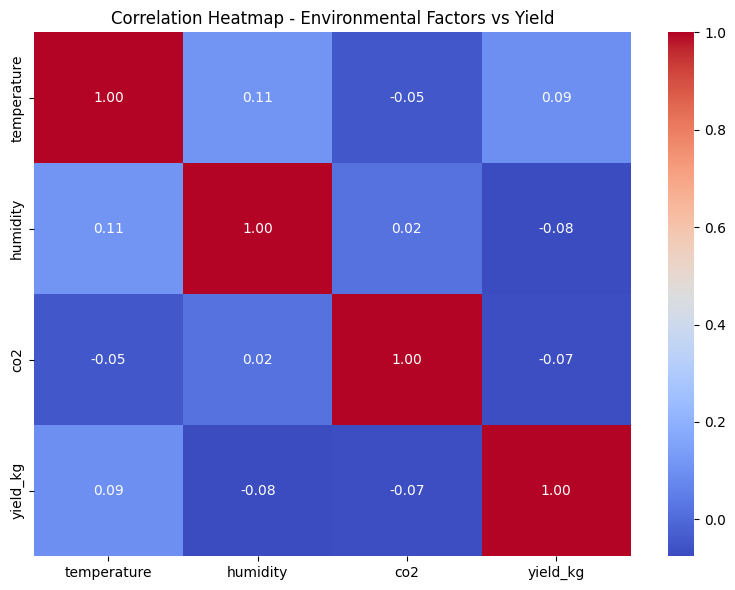

In [22]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap - Environmental Factors vs Yield")
plt.tight_layout()

plt.savefig("../reports/figures/correlation_heatmap.png")
plt.show()


In [23]:
import os

os.makedirs("../reports/figures", exist_ok=True)

print("Folder created")


Folder created


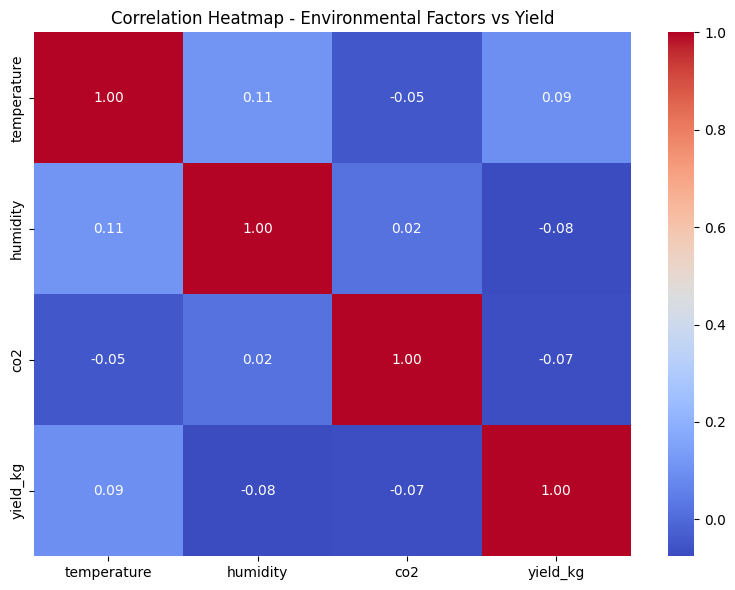

In [24]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap - Environmental Factors vs Yield")
plt.tight_layout()

plt.savefig("../reports/figures/correlation_heatmap.png")
plt.show()


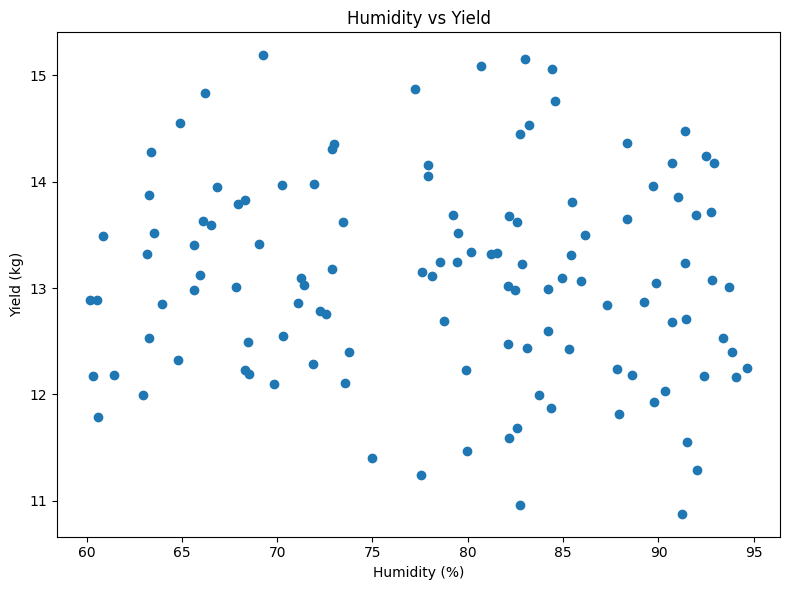

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(df["humidity"], df["yield_kg"])

plt.xlabel("Humidity (%)")
plt.ylabel("Yield (kg)")
plt.title("Humidity vs Yield")

plt.tight_layout()

plt.savefig("../reports/figures/humidity_vs_yield.png")
plt.show()

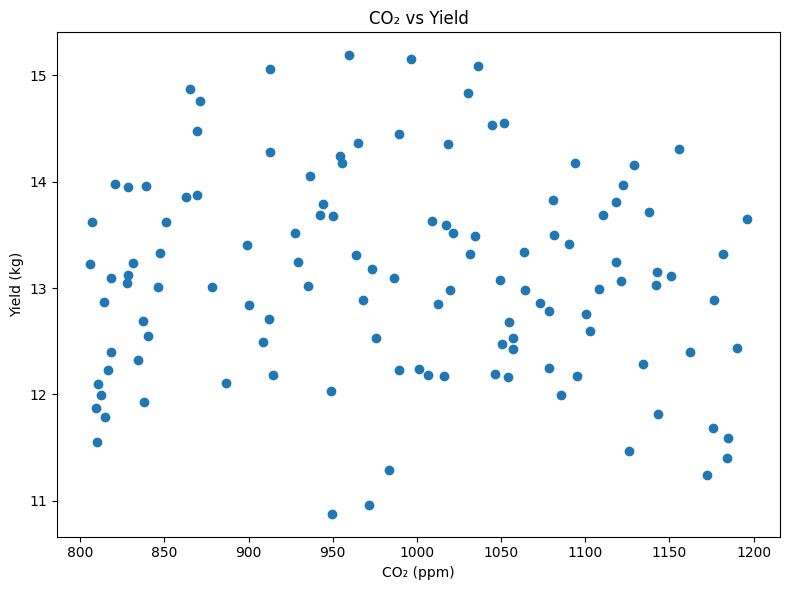

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(df["co2"], df["yield_kg"])

plt.xlabel("CO₂ (ppm)")
plt.ylabel("Yield (kg)")
plt.title("CO₂ vs Yield")

plt.tight_layout()

plt.savefig("../reports/figures/co2_vs_yield.png")
plt.show()

In [29]:
with open("../reports/eda_summary.md", "w") as f:
    f.write("# EDA Summary Report\n\n")

    f.write("## Dataset Overview\n")
    f.write(f"- Rows: {len(df)}\n")
    f.write(f"- Columns: {len(df.columns)}\n")
    f.write(f"- Start Date: {df['timestamp'].min()}\n")
    f.write(f"- End Date: {df['timestamp'].max()}\n\n")

    f.write("## Key Statistics\n\n")
    f.write(df.describe().round(2).to_markdown())
    f.write("\n\n")

    f.write("## Insights\n")
    f.write("- Humidity is moderately stable and slightly below ideal 85–90% range.\n")
    f.write("- Temperature is highly stable across the dataset.\n")
    f.write("- CO₂ shows moderate variation but remains controlled.\n")
    f.write("- Yield shows low variance, indicating consistent production.\n\n")

    f.write("## Visualizations\n")
    f.write("- Correlation heatmap\n")
    f.write("- Humidity vs Yield scatter plot\n")
    f.write("- CO₂ vs Yield scatter plot\n")

print("EDA summary saved successfully")

ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.

In [30]:
%pip install tabulate


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
with open("../reports/eda_summary.md", "w") as f:
    f.write("# EDA Summary Report\n\n")

    f.write("## Dataset Overview\n")
    f.write(f"- Rows: {len(df)}\n")
    f.write(f"- Columns: {len(df.columns)}\n")
    f.write(f"- Start Date: {df['timestamp'].min()}\n")
    f.write(f"- End Date: {df['timestamp'].max()}\n\n")

    f.write("## Key Statistics\n\n")
    f.write(df.describe().round(2).to_markdown())
    f.write("\n\n")

    f.write("## Insights\n")
    f.write("- Humidity is moderately stable and slightly below ideal range.\n")
    f.write("- Temperature is stable across dataset.\n")
    f.write("- CO₂ shows moderate variation.\n")
    f.write("- Yield is consistent with low variance.\n\n")

    f.write("## Visualizations\n")
    f.write("- Correlation heatmap\n")
    f.write("- Humidity vs Yield scatter plot\n")
    f.write("- CO₂ vs Yield scatter plot\n")

print("EDA summary saved successfully")

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/02_cleaned.csv")

print("Dataset loaded successfully")
print(df.shape)

Dataset loaded successfully
(120, 5)


In [3]:
with open("../reports/eda_summary.md", "w") as f:
    f.write("# EDA Summary Report\n\n")

    f.write("## Dataset Overview\n")
    f.write(f"- Rows: {len(df)}\n")
    f.write(f"- Columns: {len(df.columns)}\n")
    f.write(f"- Start Date: {df['timestamp'].min()}\n")
    f.write(f"- End Date: {df['timestamp'].max()}\n\n")

    f.write("## Key Statistics\n\n")
    f.write(df.describe().round(2).to_markdown())
    f.write("\n\n")

    f.write("## Insights\n")
    f.write("- Humidity is moderately stable and slightly below ideal range (85–90%).\n")
    f.write("- Temperature is highly stable across the dataset.\n")
    f.write("- CO₂ shows moderate variation but remains controlled.\n")
    f.write("- Yield is consistent with low variance, suitable for modeling.\n\n")

    f.write("## Visualizations\n")
    f.write("- Correlation heatmap\n")
    f.write("- Humidity vs Yield scatter plot\n")
    f.write("- CO₂ vs Yield scatter plot\n")

print("EDA summary saved successfully")

EDA summary saved successfully


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ModuleNotFoundError: No module named 'sklearn'

In [5]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/02_cleaned.csv")
print(df.shape)
df.head()

(120, 5)


,timestamp,temperature,humidity,co2,yield_kg
0,2025-01-01 00:00:00,25.993428,68.317314,1080.786751,13.825416
1,2025-01-01 01:00:00,24.723471,85.487572,1118.317068,13.813510
2,2025-01-01 02:00:00,26.295377,72.872410,1156.002137,14.305479
3,2025-01-01 03:00:00,28.046060,82.130704,935.198063,13.021004
4,2025-01-01 04:00:00,24.531693,82.173540,950.233181,13.681953
